#### Note: All data in this repo is synthetically made including sleep stage annotations, demographics or diseases. The data is for demo purposes only.


In [1]:
%load_ext autoreload
%autoreload 2

#### Preprocessing Details


Before running this notebook, please preprocess your PSG files using the scripts provided in `sleepfm/preprocessing`. Note that PSG recordings may contain different sets of channels across datasets. The predefined channel–modality mappings used in this project are specified in `sleepfm/configs/channel_groups.json`.

Although we have attempted to make this mapping as comprehensive as possible, we strongly recommend reviewing the channels present in your specific PSG data. In consultation with domain experts, you should group any additional or dataset-specific channels into the appropriate modality categories and update `channel_groups.json` accordingly. This step is critical to ensure that all channels are correctly aligned with their intended modalities during preprocessing and downstream modeling.

In [2]:
import torch
from torch import nn
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix
import os
import tqdm
import random
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from collections import Counter
import pandas as pd
from sleepfm.preprocessing.preprocessing import EDFToHDF5Converter
from sleepfm.models.dataset import SetTransformerDataset, collate_fn
from sleepfm.models.models import SetTransformer, SleepEventLSTMClassifier, DiagnosisFinetuneFullLSTMCOXPHWithDemo
import h5py
from sleepfm.utils import load_config, load_data, save_data, count_parameters
from torch.utils.data import Dataset, DataLoader

#### Part 0: Preprocessing EDF files

Note: This is just a demo notebook that preprocesses a single, specific file. run `sleepfm/preprocessing/preprocessing.sh` with appropriate folders to generate multiple preprocessed files.

In [3]:
base_save_path = "demo_data"
os.makedirs(base_save_path, exist_ok=True)

In [4]:
root_dir = "/edf_root"      # dummy root not used for a single file conversion
target_dir = "/note"    # dummy target not used for a single file conversion

edf_path = "demo_data/demo_psg.edf"
hdf5_path = os.path.join(base_save_path, "demo_psg.hdf5")

converter = EDFToHDF5Converter(
    root_dir=root_dir,
    target_dir=target_dir,
    resample_rate=128
)

# run for single file conversion
converter.convert(edf_path, hdf5_path)

2026-01-20 10:06:29.778 | INFO     | sleepfm.preprocessing.preprocessing:read_edf:240 - reading edf


Extracting EDF parameters from demo_data/demo_psg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 2234623  =      0.000 ...  8728.996 secs...


2026-01-20 10:06:29.977 | INFO     | sleepfm.preprocessing.preprocessing:resample_signals:283 - resampling signals


Filtering signal
Filtering signal
Filtering signal
Filtering signal


2026-01-20 10:06:30.240 | INFO     | sleepfm.preprocessing.preprocessing:save_to_hdf5:323 - saving hdf5


#### Part 1: Generating embeddings from SleepFM pretrained model

Here we show generating embedding for 1 demno PSG. To see full script, please check `sleepfm/pipeline/generate_embeddings.py`. 

In [5]:
model_path = "../checkpoints/model_base"
channel_groups_path = "../configs/channel_groups.json"
config_path = os.path.join(model_path, "config.json")

config = load_config(config_path)
channel_groups = load_data(channel_groups_path)

In [6]:
modality_types = config["modality_types"]
in_channels = config["in_channels"]
patch_size = config["patch_size"]
embed_dim = config["embed_dim"]
num_heads = config["num_heads"]
num_layers = config["num_layers"]
pooling_head = config["pooling_head"]
dropout = 0.0

In [7]:
model_class = getattr(sys.modules[__name__], config['model'])
model = model_class(in_channels, patch_size, embed_dim, num_heads, num_layers, pooling_head=pooling_head, dropout=dropout)
total_layers, total_params = count_parameters(model)
print(f'Trainable parameters: {total_params / 1e6:.2f} million')
print(f'Number of layers: {total_layers}')

Trainable parameters: 4.44 million
Number of layers: 93


/Users/ashenafee/new_development/brainhackto-2026/sleepfm/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [8]:
# Select device
USE_MPS = False

if torch.backends.mps.is_available() and USE_MPS:
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")


checkpoint = torch.load(os.path.join(model_path, "best.pt"), map_location=device)

# Remove 'module.' prefix from state_dict keys
state_dict = checkpoint["state_dict"]
new_state_dict = {}
for key, value in state_dict.items():
    if key.startswith('module.'):
        new_key = key[7:]  # Remove 'module.' prefix (7 characters)
        new_state_dict[new_key] = value
    else:
        new_state_dict[key] = value

model.load_state_dict(new_state_dict)
model.eval()

SetTransformer(
  (patch_embedding): Tokenizer(
    (tokenizer): Sequential(
      (0): Conv1d(1, 4, kernel_size=(5,), stride=(2,), padding=(2,))
      (1): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ELU(alpha=1.0)
      (3): LayerNorm((4, 320), eps=1e-05, elementwise_affine=True)
      (4): Conv1d(4, 8, kernel_size=(5,), stride=(2,), padding=(2,))
      (5): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ELU(alpha=1.0)
      (7): LayerNorm((8, 160), eps=1e-05, elementwise_affine=True)
      (8): Conv1d(8, 16, kernel_size=(5,), stride=(2,), padding=(2,))
      (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ELU(alpha=1.0)
      (11): LayerNorm((16, 80), eps=1e-05, elementwise_affine=True)
      (12): Conv1d(16, 32, kernel_size=(5,), stride=(2,), padding=(2,))
      (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [9]:
hdf5_paths = [os.path.join(base_save_path, "demo_psg.hdf5")]
dataset = SetTransformerDataset(config, channel_groups, hdf5_paths=hdf5_paths, split="test")

dataloader = torch.utils.data.DataLoader(dataset, 
                                            batch_size=16, 
                                            num_workers=1, 
                                            shuffle=False, 
                                            collate_fn=collate_fn)

Indexing files: 100%|██████████| 1/1 [00:00<00:00,  1.27it/s]


In [10]:
output = os.path.join(base_save_path, "demo_emb")
output_5min_agg = os.path.join(base_save_path, "demo_5min_agg_emb")
os.makedirs(output, exist_ok=True)
os.makedirs(output_5min_agg, exist_ok=True)

In [11]:
with torch.no_grad():
    with tqdm.tqdm(total=len(dataloader)) as pbar:
        for batch in dataloader:
            batch_data, mask_list, file_paths, dset_names_list, chunk_starts = batch
            (bas, resp, ekg, emg) = batch_data
            (mask_bas, mask_resp, mask_ekg, mask_emg) = mask_list

            bas = bas.to(device, dtype=torch.float)
            resp = resp.to(device, dtype=torch.float)
            ekg = ekg.to(device, dtype=torch.float)
            emg = emg.to(device, dtype=torch.float)

            mask_bas = mask_bas.to(device, dtype=torch.bool)
            mask_resp = mask_resp.to(device, dtype=torch.bool)
            mask_ekg = mask_ekg.to(device, dtype=torch.bool)
            mask_emg = mask_emg.to(device, dtype=torch.bool)

            embeddings = [
                model(bas, mask_bas),
                model(resp, mask_resp),
                model(ekg, mask_ekg),
                model(emg, mask_emg),
            ]

            # Model gives two kinds of embeddings. Granular 5 second-level embeddings and aggregated 5 minute-level embeddings. We save both of them below.

            embeddings_new = [e[0].unsqueeze(1) for e in embeddings]

            for i in range(len(file_paths)):
                file_path = file_paths[i]
                chunk_start = chunk_starts[i]
                subject_id = os.path.basename(file_path).split(".")[0]
                output_path = os.path.join(output_5min_agg, f"{subject_id}.hdf5")

                with h5py.File(output_path, "a") as hdf5_file:
                    for modality_idx, modality_type in enumerate(
                        config["modality_types"]
                    ):
                        if modality_type in hdf5_file:
                            dset = hdf5_file[modality_type]
                            chunk_start_correct = chunk_start // (embed_dim * 5 * 60)
                            chunk_end = (
                                chunk_start_correct
                                + embeddings_new[modality_idx][i].shape[0]
                            )
                            if dset.shape[0] < chunk_end:
                                dset.resize(
                                    (chunk_end,)
                                    + embeddings_new[modality_idx][i].shape[1:]
                                )
                            dset[chunk_start_correct:chunk_end] = (
                                embeddings_new[modality_idx][i].cpu().numpy()
                            )
                        else:
                            hdf5_file.create_dataset(
                                modality_type,
                                data=embeddings_new[modality_idx][i].cpu().numpy(),
                                chunks=(embed_dim,)
                                + tuple(embeddings_new[modality_idx][i].shape[1:]),
                                maxshape=(None,)
                                + tuple(embeddings_new[modality_idx][i].shape[1:]),
                            )

            embeddings_new = [e[1] for e in embeddings]

            for i in range(len(file_paths)):
                file_path = file_paths[i]
                chunk_start = chunk_starts[i]
                subject_id = os.path.basename(file_path).split(".")[0]
                output_path = os.path.join(output, f"{subject_id}.hdf5")

                with h5py.File(output_path, "a") as hdf5_file:
                    for modality_idx, modality_type in enumerate(
                        config["modality_types"]
                    ):
                        if modality_type in hdf5_file:
                            dset = hdf5_file[modality_type]
                            chunk_start_correct = chunk_start // (embed_dim * 5)
                            chunk_end = (
                                chunk_start_correct
                                + embeddings_new[modality_idx][i].shape[0]
                            )
                            if dset.shape[0] < chunk_end:
                                dset.resize(
                                    (chunk_end,)
                                    + embeddings_new[modality_idx][i].shape[1:]
                                )
                            dset[chunk_start_correct:chunk_end] = (
                                embeddings_new[modality_idx][i].cpu().numpy()
                            )
                        else:
                            hdf5_file.create_dataset(
                                modality_type,
                                data=embeddings_new[modality_idx][i].cpu().numpy(),
                                chunks=(embed_dim,)
                                + tuple(embeddings_new[modality_idx][i].shape[1:]),
                                maxshape=(None,)
                                + tuple(embeddings_new[modality_idx][i].shape[1:]),
                            )
            pbar.update()

100%|██████████| 2/2 [00:07<00:00,  3.84s/it]


#### Part 2: Sleep Staging

Note that below, we are using our finetuned sleep staging model. It is always a good idea to finetune our model on your specific data, even if you only have a handful of sample, so that the model can adapt to your specific data distribution. Script to finetune your sleep staging model head is given in `sleepfm/pipeline/finetune_sleep_staging.py`. 

In [12]:
sleep_staging_model_path = "../checkpoints/model_sleep_staging"
sleep_staging_config = load_data(os.path.join(sleep_staging_model_path, "config.json"))

sleep_staging_model_params = sleep_staging_config['model_params']
sleep_staging_model_class = getattr(sys.modules[__name__], sleep_staging_config['model'])

sleep_staging_model = sleep_staging_model_class(**sleep_staging_model_params).to(device)
sleep_staging_model_name = type(sleep_staging_model).__name__

/Users/ashenafee/new_development/brainhackto-2026/sleepfm/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [13]:
sleep_staging_model = nn.DataParallel(sleep_staging_model)
print(f"Using {torch.cuda.device_count()} GPUs")

Using 0 GPUs


In [14]:
print(f"Model initialized: {sleep_staging_model_name}")
total_layers, total_params = count_parameters(sleep_staging_model)
print(f'Trainable parameters: {total_params / 1e6:.2f} million')
print(f'Number of layers: {total_layers}')

Model initialized: SleepEventLSTMClassifier
Trainable parameters: 1.19 million
Number of layers: 20


In [15]:
sleep_staging_checkpoint_path = os.path.join(sleep_staging_model_path, "best.pth")
sleep_staging_checkpoint = torch.load(sleep_staging_checkpoint_path, map_location=device)
sleep_staging_model.load_state_dict(sleep_staging_checkpoint)

<All keys matched successfully>

Below are some helper functions for loading data for sleep staging. You can find similar functions within `sleepfm/models/dataset.py`. You may need to modify it slightly based on your usecase.

**Note**: We extracted the original Python code block defining `SleepEventClassificationDataset` and `sleep_event_finetune_full_collate_fn` from the notebook so unpickling can work correctly. This is a separate module from `sleepfm/models/dataset.py` because it has its own `SleepEventClassificationDataset` class (and we will need to consolidate soon).

In [16]:
from sleepfm.data.demo import SleepEventClassificationDataset, sleep_event_finetune_full_collate_fn

In [17]:
hdf5_paths = [os.path.join(base_save_path, "demo_emb/demo_psg.hdf5")]
label_files = [os.path.join(base_save_path, "demo_psg.csv")]
test_dataset = SleepEventClassificationDataset(sleep_staging_config, channel_groups, split="test", hdf5_paths=hdf5_paths, label_files=label_files)

In [18]:
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=1, collate_fn=sleep_event_finetune_full_collate_fn)

In [19]:
# Validation loop at the end of each epoch
model.eval()
all_targets = []
all_logits = []
all_outputs = []
all_masks = []
all_paths = []

count = 0
with torch.no_grad():
    for (x_data, y_data, padded_matrix, hdf5_path_list) in tqdm.tqdm(test_loader, desc="Evaluating"):
        x_data, y_data, padded_matrix, hdf5_path_list = x_data.to(device), y_data.to(device), padded_matrix.to(device), list(hdf5_path_list)
        outputs, mask = sleep_staging_model(x_data, padded_matrix)
        all_targets.append(y_data.cpu().numpy())
        all_outputs.append(torch.softmax(outputs, dim=-1).cpu().numpy())
        all_logits.append(outputs.cpu().numpy())
        all_masks.append(mask.cpu().numpy())
        all_paths.append(hdf5_path_list)


save_path = os.path.join(base_save_path, "demo_sleep_staging")
os.makedirs(save_path, exist_ok=True)

targets_path = os.path.join(save_path, "all_targets.pickle")
outputs_path = os.path.join(save_path, "all_outputs.pickle")
logits_path = os.path.join(save_path, "all_logits.pickle")
mask_path = os.path.join(save_path, "all_masks.pickle")
file_paths = os.path.join(save_path, "all_paths.pickle")

save_data(all_targets, targets_path)
save_data(all_outputs, outputs_path)
save_data(all_logits, logits_path)
save_data(all_masks, mask_path)
save_data(all_paths, file_paths)

Evaluating: 100%|██████████| 1/1 [00:06<00:00,  6.12s/it]


In [20]:
all_outputs[0].shape, all_targets[0].shape

((1, 1740, 5), (1, 1740))

In [21]:
len(all_logits), len(all_outputs), len(all_targets), len(all_masks)

(1, 1, 1, 1)

In [22]:
all_logits[0].shape, all_outputs[0].shape, all_targets[0].shape, all_masks[0].shape

((1, 1740, 5), (1, 1740, 5), (1, 1740), (1, 1740))

In [23]:
all_logits_flat = [logits.reshape(-1, logits.shape[-1]) for logits in all_logits]
all_outputs_flat = [outputs.reshape(-1, outputs.shape[-1]) for outputs in all_outputs]
all_targets_flat = [targets.reshape(-1) for targets in all_targets]
all_masks_flat = [mask.reshape(-1) for mask in all_masks]

# Convert lists of flattened arrays to single concatenated arrays if desired
all_logits_flat = np.concatenate(all_logits_flat, axis=0)
all_outputs_flat = np.concatenate(all_outputs_flat, axis=0)
all_targets_flat = np.concatenate(all_targets_flat, axis=0)
all_masks_flat = np.concatenate(all_masks_flat, axis=0)

In [24]:
all_logits_flat.shape, all_outputs_flat.shape, all_targets_flat.shape, all_masks_flat.shape

((1740, 5), (1740, 5), (1740,), (1740,))

In [25]:
mask_filter = all_masks_flat == 0

# Apply the mask to each flattened array
all_logits_filtered = all_logits_flat[mask_filter]
all_outputs_filtered = all_outputs_flat[mask_filter]
all_targets_filtered = all_targets_flat[mask_filter]

In [26]:
counts = Counter(all_targets_filtered)
total = sum(counts.values())
prevalence_dict = {cls: count / total for cls, count in counts.items()}
prevalence_dict

{np.float32(0.0): 0.367816091954023,
 np.float32(1.0): 0.1511494252873563,
 np.float32(4.0): 0.16839080459770114,
 np.float32(3.0): 0.15402298850574714,
 np.float32(2.0): 0.15862068965517243}

In [27]:
class_labels = ["Wake", "Stage 1", "Stage 2", "Stage 3", "REM"]
# class_labels = ["No-Apnea", "Apnea"]
class_mapping = {label: idx for idx, label in enumerate(class_labels)}

F1 Score for Wake: 0.538
F1 Score for Stage 1: 0.000
F1 Score for Stage 2: 0.000
F1 Score for Stage 3: 0.000
F1 Score for REM: 0.000


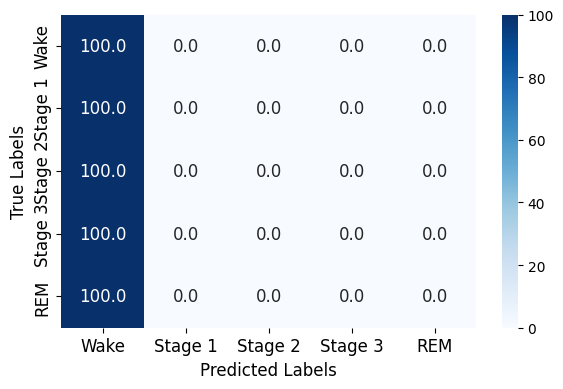

In [28]:
# Step 1: Get predicted labels (argmax on probabilities)
predicted_labels = np.argmax(all_outputs_filtered, axis=1)

fontsize = 12

# Step 2: Compute F1 score for each class
f1_scores = f1_score(all_targets_filtered, predicted_labels, average=None, labels=range(len(class_labels)))
for idx, label in enumerate(class_labels):
    print(f"F1 Score for {label}: {f1_scores[idx]:.3f}")

# Step 3: Create a confusion matrix and normalize it by row to get percentages
conf_matrix = confusion_matrix(all_targets_filtered, predicted_labels, labels=range(len(class_labels)))
conf_matrix_percent = conf_matrix / conf_matrix.sum(axis=1, keepdims=True) * 100

# Plotting the confusion matrix with percentages
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix_percent,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
    annot_kws={"size": fontsize},  # Font size for numbers inside the heatmap
    cbar_kws={"shrink": 1},  # Adjust colorbar size
)

# Customizing axis labels and ticks
plt.xlabel("Predicted Labels", fontsize=fontsize)
plt.ylabel("True Labels", fontsize=fontsize)
plt.xticks(fontsize=12, ha="center")  # Font size for x-axis tick labels with rotation
plt.yticks(fontsize=12)  # Font size for y-axis tick labels

# Adjust layout and save the figure
plt.tight_layout()
plt.show()

#### Part 3: Disease Prediction

In [29]:
disease_model_path = "../checkpoints/model_diagnosis"
config = load_data(os.path.join(disease_model_path, "config.json"))

In [30]:
config["model_params"]["dropout"] = 0.0
model_params = config['model_params']
model_class = getattr(sys.modules[__name__], config['model'])
model = model_class(**model_params).to(device)
model_name = type(model).__name__

In [31]:
model = nn.DataParallel(model)
print(f"Model initialized: {model_name}")
total_layers, total_params = count_parameters(model)
print(f'Trainable parameters: {total_params / 1e6:.2f} million')
print(f'Number of layers: {total_layers}')

Model initialized: DiagnosisFinetuneFullLSTMCOXPHWithDemo
Trainable parameters: 0.91 million
Number of layers: 15


In [32]:
checkpoint_path = os.path.join(disease_model_path, "best.pth")

In [33]:
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [34]:
save_path = os.path.join(base_save_path, "demo_diagnosis")
os.makedirs(save_path, exist_ok=True)

In [35]:
from sleepfm.data.demo import DiagnosisFinetuneFullCOXPHWithDemoDataset, diagnosis_finetune_full_coxph_with_demo_collate_fn


hdf5_paths = [os.path.join(base_save_path, "demo_emb/demo_psg.hdf5")]
demo_labels_path = os.path.join(base_save_path, "demo_age_gender.csv")
config["labels_path"] = base_save_path

test_dataset = DiagnosisFinetuneFullCOXPHWithDemoDataset(config, channel_groups, split="test", hdf5_paths=hdf5_paths, demo_labels_path=demo_labels_path)

  0%|          | 0/1 [00:00<?, ?it/s]

Number of files in test set: 1
Number of files to be processed in test set: 1


In [36]:
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=1, collate_fn=diagnosis_finetune_full_coxph_with_demo_collate_fn)

In [37]:
model.eval()
all_event_times = []
all_is_event = []
all_outputs = []
all_paths = []

with torch.no_grad():
    for item in tqdm.tqdm(test_loader, desc="Evaluating"):
        x_data, event_times, is_event, demo_feats, padded_matrix, hdf5_path_list = item
        x_data, event_times, is_event, demo_feats, padded_matrix, hdf5_path_list = x_data.to(device), event_times.to(device), is_event.to(device), demo_feats.to(device), padded_matrix.to(device), list(hdf5_path_list)
        outputs = model(x_data, padded_matrix, demo_feats)
    
        logits = outputs.cpu().numpy()
        all_outputs.append(logits)
        all_event_times.append(event_times.cpu().numpy())
        all_is_event.append(is_event.cpu().numpy())
        all_paths.append(hdf5_path_list)

all_outputs = np.concatenate(all_outputs, axis=0)
all_event_times = np.concatenate(all_event_times, axis=0)
all_is_event = np.concatenate(all_is_event, axis=0)
all_paths = np.concatenate(all_paths)

outputs_path = os.path.join(save_path, "all_outputs.pickle")
event_times_path = os.path.join(save_path, "all_event_times.pickle")
is_event_path = os.path.join(save_path, "all_is_event.pickle")
file_paths = os.path.join(save_path, "all_paths.pickle")

save_data(all_outputs, outputs_path)
save_data(all_event_times, event_times_path)
save_data(all_is_event, is_event_path)
save_data(all_paths, file_paths)

Evaluating: 100%|██████████| 1/1 [00:06<00:00,  6.10s/it]


In [38]:
all_outputs.shape, all_event_times.shape, all_is_event.shape

((1, 1065), (1, 1065), (1, 1065))

Above, you get the model outputs, which you can then use to look for specific disease diagnosis. Nope that the shape of the output above is 1065, meaning, this model gives logprobs for 1065 conditions. We provide information about each disease index and its corresponding phecode here `sleepfm/configs/label_mapping.csv`. You can map it as follows. 

In [39]:
labels_df = pd.read_csv("../configs/label_mapping.csv")

In [40]:
labels_df["output"] = all_outputs[0]
labels_df["is_event"] = all_is_event[0]
labels_df["event_time"] = all_event_times[0]

In [41]:
labels_df.head()

,label_idx,phecode,phenotype,output,is_event,event_time
0,0,8.0,Intestinal infection,2.382297,0,3845.0
1,1,8.5,Bacterial enteritis,2.941347,0,3845.0
2,2,8.6,Viral Enteritis,3.220719,0,3845.0
3,3,38.0,Septicemia,5.640467,0,3845.0
4,4,38.3,Bacteremia,5.597488,0,3845.0


Above, you get the output hazards from our model, and also your labels for is_event and event_times. Is_event is an indicator for if the event occured and event_time is the time to event